# Preprocessing the MNIST dataset

In this notebook, I'm walking through how I pre-processed the MNIST dataset to make it variable in length. The original dataset only has single digit images.

First, load the requirements. 

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
import random


# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print("Setup complete!")

PyTorch version: 2.10.0
Setup complete!


Next, load the MNIST dataset. This will create a [data](../data) directory in your workspace.

In [ ]:
# Load the MNIST dataset
dataset = MNIST(root = '../data/MNIST/', 
                download = True,
                transform = transforms.ToTensor())

# Print out dataset information
print(dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../data/MNIST/
    Split: Train
    StandardTransform
Transform: ToTensor()


Here is an example of what the images from the dataset look like before preprocessing them.

torch.Size([1, 28, 28]) 5
torch.Size([1, 28, 28]) 0
torch.Size([1, 28, 28]) 4
torch.Size([1, 28, 28]) 1
torch.Size([1, 28, 28]) 9


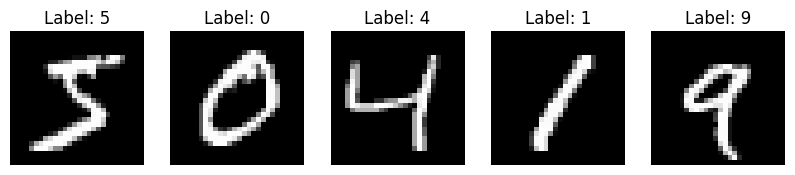

In [5]:
## Print out the first 5 images by plotting the tensors
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    image_tensor, label = dataset[i]
    print(image_tensor.shape, label)
    axes[i].imshow(image_tensor[0, 0:28, 0:28], cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")
plt.show()

To make this dataset useful for multi-digits, I want to create 2 and 3 digit versions of this dataset. One consideration to keep in mind is I want the final image or tensor for 1, 2, and 3 digit numbers to all have the same dimensions so they cannot be classified simply based on size.

In [6]:
import torch
import random
import torch.nn.functional as F

MAX_DIGITS = 3
DIGIT_WIDTH = 28
FINAL_WIDTH = MAX_DIGITS * DIGIT_WIDTH  # 84

def create_multi_digit(dataset, num_digits=None):
    
    if num_digits is None:
        num_digits = random.randint(1, MAX_DIGITS)

    images = []
    labels = []

    # Get three random digits and their labels
    for _ in range(num_digits):
        idx = random.randint(0, len(dataset)-1)
        img, label = dataset[idx]
        images.append(img)
        labels.append(str(label))

    # Concatenate digits
    multi_img = torch.cat(images, dim=2)

    # Pad to fixed width
    current_width = multi_img.shape[2]
    pad_width = FINAL_WIDTH - current_width

    multi_img = F.pad(multi_img, (0, pad_width))  # pad right side only

    multi_label = int("".join(labels))

    return multi_img, multi_label

In [7]:
test_digit = create_multi_digit(dataset, num_digits=2)

In [11]:
test_digit

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 73)

torch.Size([1, 28, 84]) 73


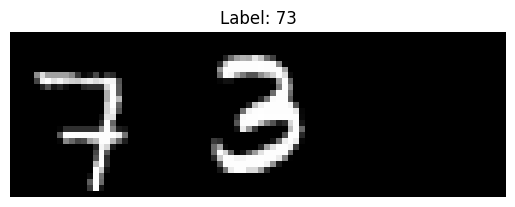

In [13]:
image_tensor, label = test_digit
print(image_tensor.shape, label)

plt.imshow(image_tensor[0, 0:28, 0:84], cmap='gray')
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()